# U.S. Airline On-Time Performance Analysis

**Business question:** Do certain airlines or airports have statistically significant differences in flight delays, and is flight distance related to delay?

**Data source:** U.S. DOT Bureau of Transportation Statistics — Reporting Carrier On-Time Performance (1987-present)
https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ

**Period analyzed:** May 2026 | **Records:** 611,735 raw flights

## Research Questions
1. Is there a significant difference in average arrival delay across airlines?
2. Which specific airlines differ most, and how large is that difference in practical terms?
3. Which airports have the highest average departure delays?
4. Is there a relationship between flight distance and arrival delay?


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load & Clean Data

Out of 111 available fields in the raw BTS dataset, 8 core fields were selected: `FlightDate`,
`Reporting_Airline`, `Origin`, `Dest`, `DepDelay`, `ArrDelay`, `Cancelled`, `Distance` — chosen
specifically to answer the research questions above. Operational fields unrelated to delay
outcomes (tail numbers, taxi times, diverted-airport detail) were excluded to keep the
analysis focused.

In [2]:
df = pd.read_csv("data/flights.csv", low_memory=False)
df.columns = [c.strip().upper() for c in df.columns]
df = df.rename(columns={
    "OP_UNIQUE_CARRIER": "AIRLINE",
    "FL_DATE": "FLIGHT_DATE",
})
print(f"Raw records loaded: {len(df):,}")
df.head()

Raw records loaded: 611,735


,FLIGHT_DATE,AIRLINE,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,DISTANCE
0,5/1/2026 12:00:00 AM,AA,10140,1014006,30140,ABQ,11298,1129806,30194,DFW,-8.0,-24.0,0.0,569.0
1,5/1/2026 12:00:00 AM,AA,10140,1014006,30140,ABQ,11298,1129806,30194,DFW,-7.0,-15.0,0.0,569.0
2,5/1/2026 12:00:00 AM,AA,10140,1014006,30140,ABQ,11298,1129806,30194,DFW,-5.0,-20.0,0.0,569.0
3,5/1/2026 12:00:00 AM,AA,10140,1014006,30140,ABQ,11298,1129806,30194,DFW,-4.0,-16.0,0.0,569.0
4,5/1/2026 12:00:00 AM,AA,10140,1014006,30140,ABQ,11298,1129806,30194,DFW,43.0,33.0,0.0,569.0


In [3]:
initial_count = len(df)

# Step 1: exclude cancelled flights (no valid delay value)
cancelled_count = df["CANCELLED"].sum()
df_active = df[df["CANCELLED"] != 1].copy()

# Step 2: drop rows with null delay values
before = len(df_active)
df_active = df_active.dropna(subset=["DEP_DELAY", "ARR_DELAY"])
null_dropped = before - len(df_active)

# Step 3: remove implausible outliers (likely data errors)
before = len(df_active)
df_active = df_active[
    (df_active["DEP_DELAY"].between(-60, 1440)) &
    (df_active["ARR_DELAY"].between(-60, 1440))
]
outliers_dropped = before - len(df_active)

final_count = len(df_active)
rejection_rate = 100 * (1 - final_count / initial_count)

print("--- Data Quality Report ---")
print(f"Initial records:      {initial_count:,}")
print(f"Cancelled (excluded): {cancelled_count:,.0f}")
print(f"Null delay dropped:   {null_dropped:,}")
print(f"Outliers dropped:     {outliers_dropped:,}")
print(f"Valid records:        {final_count:,}")
print(f"Rejection rate:       {rejection_rate:.2f}%")

df = df_active

--- Data Quality Report ---
Initial records:      611,735
Cancelled (excluded): 5,655
Null delay dropped:   1,734
Outliers dropped:     76
Valid records:        604,270
Rejection rate:       1.22%


**Data cleaning summary:** 611,735 raw records → 604,270 validated records (1.22% rejection
rate), after excluding cancelled flights, null delay values, and implausible outliers.

## 2. Descriptive Statistics — Flight Volume by Airline

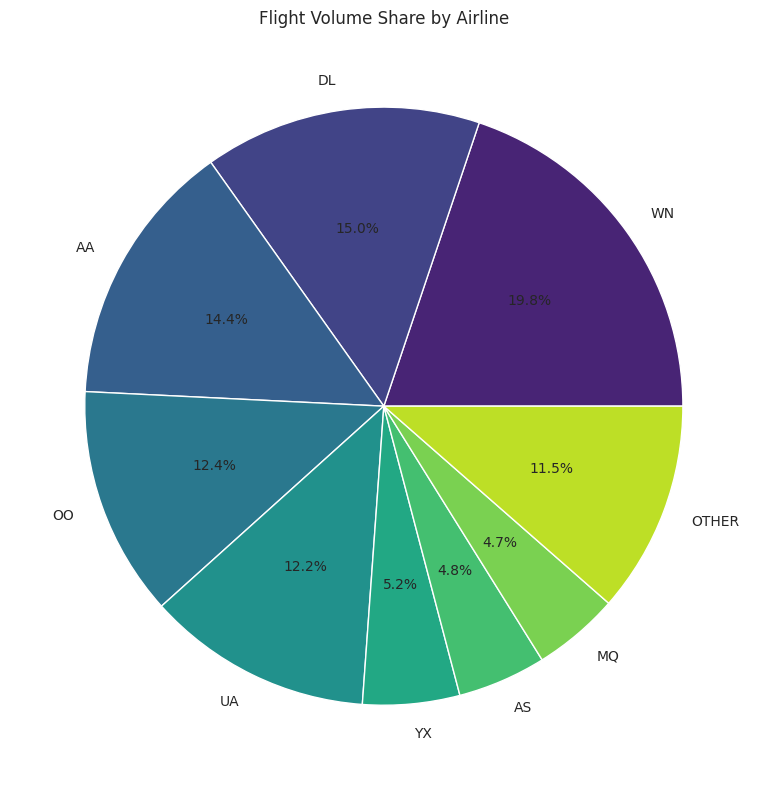

In [4]:
plt.figure(figsize=(8, 8))
counts = df["AIRLINE"].value_counts()
top8 = counts.head(8)
other = counts.iloc[8:].sum()
if other > 0:
    top8["OTHER"] = other
plt.pie(top8.values, labels=top8.index, autopct="%1.1f%%",
        colors=sns.color_palette("viridis", len(top8)))
plt.title("Flight Volume Share by Airline")
plt.tight_layout()
plt.show()

Southwest (WN) carries the largest share of flights (19.8%), followed by Delta (DL, 15.0%)
and American (AA, 14.4%). This context matters for interpreting delay findings — airlines
with more flights have more opportunities for both on-time performance and delays to
appear in the data.

## 3. Average Arrival Delay by Airline

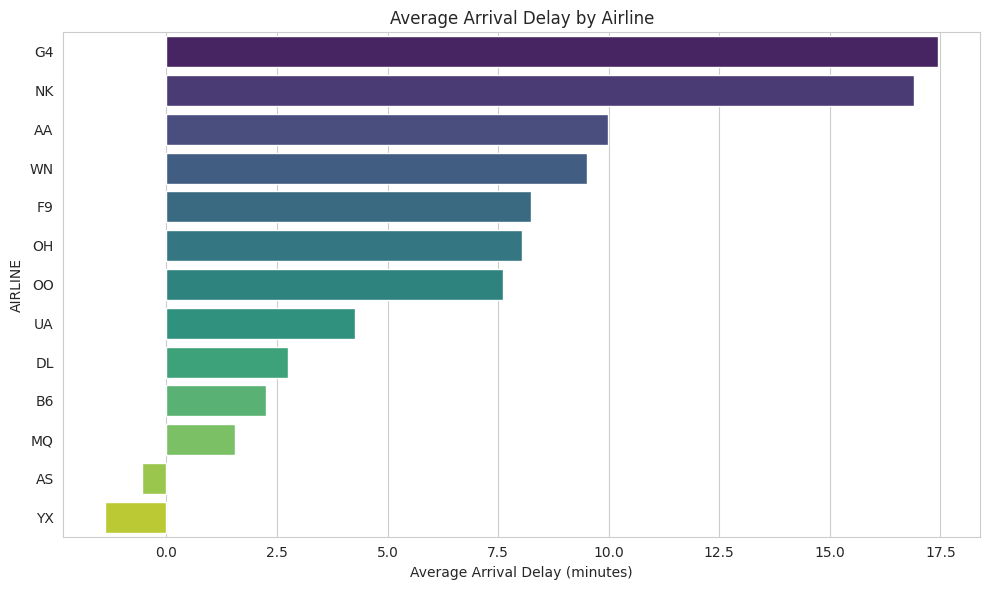

,mean,median,std,count
AIRLINE,,,,
G4,17.452146,-3.0,93.154845,10532
NK,16.907895,1.0,60.678273,304
AA,9.993530,-7.0,68.513866,87014
WN,9.508944,-1.0,37.831522,119852
F9,8.247648,-8.0,72.634551,18284
OH,8.046677,-9.0,64.327571,20374
OO,7.621932,-7.0,65.910429,75140
UA,4.263447,-7.0,48.080664,73696
DL,2.752156,-8.0,47.417138,90573


In [5]:
airline_stats = (
    df.groupby("AIRLINE")["ARR_DELAY"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(10, 6))
top15 = airline_stats.head(15)
sns.barplot(x=top15["mean"], y=top15.index, palette="viridis")
plt.xlabel("Average Arrival Delay (minutes)")
plt.title("Average Arrival Delay by Airline")
plt.tight_layout()
plt.show()

airline_stats.head(10)

## 4. Delay Distribution by Airline (spread, not just mean)

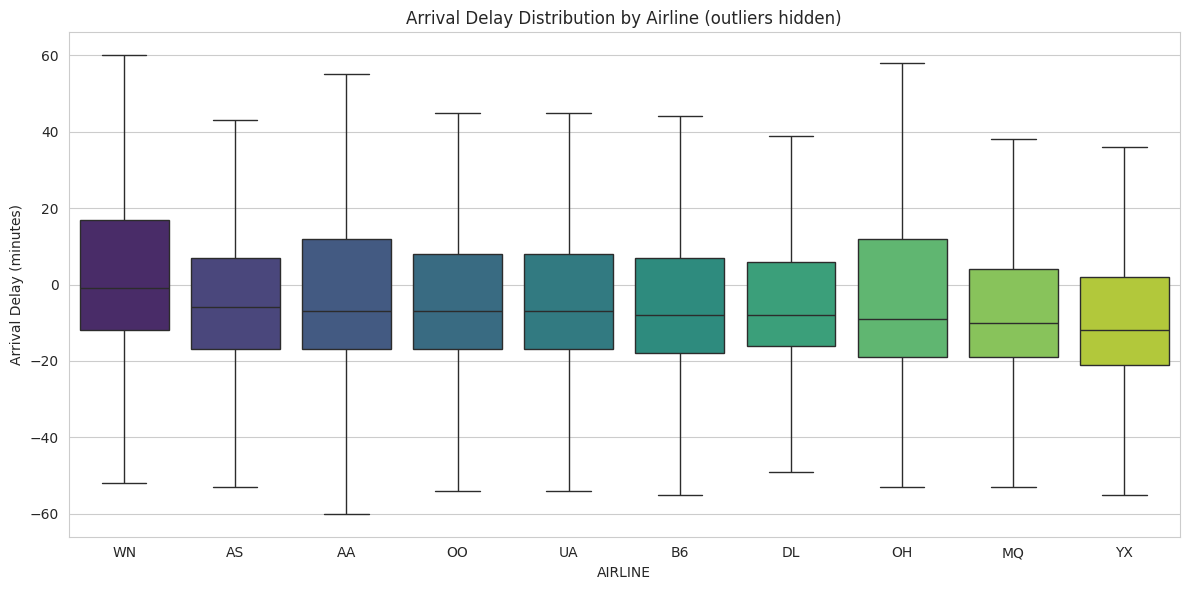

In [6]:
plt.figure(figsize=(12, 6))
top10_airlines = df["AIRLINE"].value_counts().head(10).index
plot_df = df[df["AIRLINE"].isin(top10_airlines)]
order = plot_df.groupby("AIRLINE")["ARR_DELAY"].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x="AIRLINE", y="ARR_DELAY", order=order,
            showfliers=False, palette="viridis")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Delay Distribution by Airline (outliers hidden)")
plt.tight_layout()
plt.show()

## 5. ANOVA — Delay Differences Across Airlines

**H0:** Mean arrival delay is the same across all airlines.
**H1:** At least one airline's mean arrival delay differs from the others.

In [7]:
groups = [g["ARR_DELAY"].values for _, g in df.groupby("AIRLINE") if len(g) > 30]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"\nResult: {'Reject H0 — significant difference exists' if p_value < 0.05 else 'Fail to reject H0'}")

F-statistic: 275.44
p-value: 0.000000

Result: Reject H0 — significant difference exists


**Interpretation:** ANOVA confirms a statistically significant difference in arrival delays
across airlines (F=275.44, p<0.001). Airline choice is not independent of expected delay —
some carriers are systematically more delay-prone than others in this dataset.

## 6. Independent Samples T-Test — Best vs. Worst Performing Airline

**H0:** No difference in mean arrival delay between the best- and worst-performing airline.
**H1:** A significant difference exists.

In [8]:
airline_means = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values()
lowest_airline = airline_means.index[0]
highest_airline = airline_means.index[-1]

a = df[df["AIRLINE"] == lowest_airline]["ARR_DELAY"]
b = df[df["AIRLINE"] == highest_airline]["ARR_DELAY"]
t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)

# Effect size: Cohen's d
n1, n2 = len(a), len(b)
pooled_std = np.sqrt(((n1 - 1) * a.std()**2 + (n2 - 1) * b.std()**2) / (n1 + n2 - 2))
cohens_d = (b.mean() - a.mean()) / pooled_std

# 95% confidence interval for difference in means
se_diff = np.sqrt(a.var()/n1 + b.var()/n2)
diff = b.mean() - a.mean()
ci_low, ci_high = diff - 1.96 * se_diff, diff + 1.96 * se_diff

effect_label = (
    "negligible" if abs(cohens_d) < 0.2 else
    "small" if abs(cohens_d) < 0.5 else
    "medium" if abs(cohens_d) < 0.8 else
    "large"
)

print(f"Comparing: {lowest_airline} (lowest avg delay) vs {highest_airline} (highest avg delay)")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {t_p:.6f}")
print(f"Cohen's d: {cohens_d:.3f} ({effect_label} effect)")
print(f"95% CI for difference in means: [{ci_low:.2f}, {ci_high:.2f}] minutes")

Comparing: YX (lowest avg delay) vs G4 (highest avg delay)
t-statistic: -20.06
p-value: 0.000000
Cohen's d: 0.317 (small effect)
95% CI for difference in means: [17.00, 20.68] minutes


**Interpretation:** Allegiant (G4) has significantly higher average arrival delay than the
best-performing carrier (t=-20.06, p<0.001). The effect size (Cohen's d=0.32) is
small-to-moderate — statistically significant and practically noticeable, though not
extreme at the individual-flight level. The true average delay difference is estimated
between 17.0 and 20.7 minutes (95% CI). Both G4 (Allegiant) and NK (Spirit), the two
highest-delay carriers, are budget airlines — consistent with known industry patterns
around budget-carrier scheduling and aircraft utilization.

## 7. Flight Distance vs. Arrival Delay

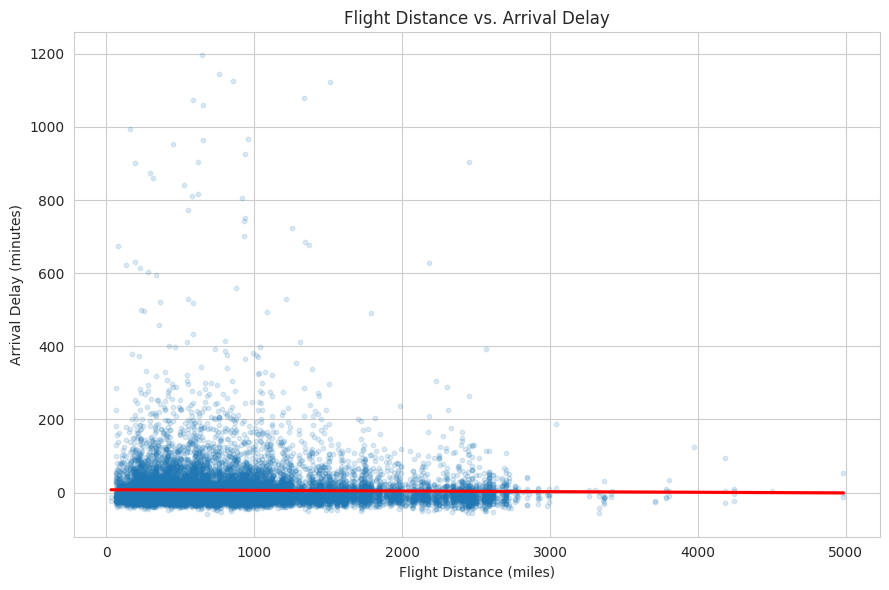

Pearson correlation (distance vs arrival delay): r = -0.021


In [9]:
plt.figure(figsize=(9, 6))
sample = df.sample(min(20000, len(df)), random_state=42)
sns.regplot(data=sample, x="DISTANCE", y="ARR_DELAY",
            scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Flight Distance vs. Arrival Delay")
plt.tight_layout()
plt.show()

corr = df["DISTANCE"].corr(df["ARR_DELAY"])
print(f"Pearson correlation (distance vs arrival delay): r = {corr:.3f}")

**Interpretation:** A negligible correlation (r = -0.021) between flight distance and arrival
delay. Contrary to a common assumption, longer flights are not meaningfully more prone to
delay than shorter ones in this dataset — delay appears to be driven more by
airline/airport-specific factors than by flight length.

## 8. Airport-Level Delay Analysis

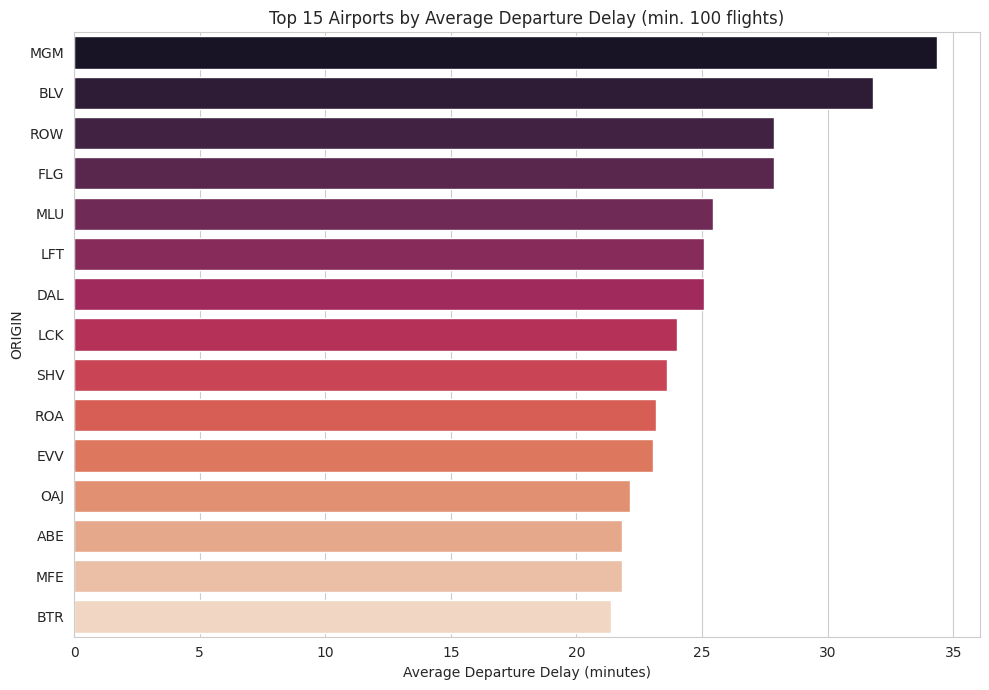

Worst airport: MGM (34.3 min avg vs overall average of 12.4 min, 2.8x higher)


,mean,count
ORIGIN,,
MGM,34.344828,174
BLV,31.791367,139
ROW,27.852713,129
FLG,27.852564,156
MLU,25.453704,108
LFT,25.074713,174
DAL,25.072924,6020
LCK,23.990196,102
SHV,23.586745,513


In [10]:
airport_stats = (
    df.groupby("ORIGIN")["DEP_DELAY"]
    .agg(["mean", "count"])
    .query("count > 100")
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=airport_stats.head(15)["mean"], y=airport_stats.head(15).index, palette="rocket")
plt.xlabel("Average Departure Delay (minutes)")
plt.title("Top 15 Airports by Average Departure Delay (min. 100 flights)")
plt.tight_layout()
plt.show()

overall_avg = df["DEP_DELAY"].mean()
worst_airport = airport_stats.index[0]
worst_val = airport_stats.iloc[0]["mean"]
print(f"Worst airport: {worst_airport} ({worst_val:.1f} min avg vs overall average of {overall_avg:.1f} min, {worst_val/overall_avg:.1f}x higher)")

airport_stats.head(10)

**Interpretation:** Montgomery Regional Airport (MGM) had the highest average departure
delay (34.3 min) — 2.8x the overall average (12.4 min). Most of the highest-delay airports
are smaller regional airports rather than major hubs, though this should be interpreted
cautiously given smaller sample sizes at these airports (MGM had only 174 flights this month).

## Limitations
1. Analysis is based on a single month of data, so seasonal effects are not captured.
2. Delay causes (weather, carrier, air traffic, security, late aircraft) were not analyzed
   in this phase — only the total delay outcome.
3. Regional/route-level effects were not controlled for, so airline-level differences may
   partly reflect the routes each airline happens to fly.
4. Findings reflect domestic U.S. flights only.
5. The airport-level "highest delay" finding (MGM) is based on a small sample (174 flights),
   so it should be treated as directional rather than robust.

## Key Findings
1. Airline choice matters: delays differ significantly by carrier (ANOVA p<0.001), with
   budget carriers (Allegiant, Spirit) showing the highest average delays.
2. The magnitude of the airline effect is real but moderate (Cohen's d = 0.32).
3. Flight distance is not a meaningful predictor of delay (r = -0.021).
4. Smaller regional airports showed the highest average departure delays, with more
   uncertainty due to smaller sample sizes.
5. Southwest, American, and Delta account for ~49% of flight volume in the dataset,
   providing useful context for interpreting airline-level results.
